# Etsy AI-Generated Image Detection — Getting Started

## Problem

Etsy is a two-sided marketplace connecting millions of independent sellers with buyers worldwide. Some sellers misrepresent their listings by using **AI-generated images** (Midjourney, DALL-E, Stable Diffusion, etc.) instead of authentic product photos.

**Task:** Binary classification — given a listing image, predict:
- `1` → AI-generated
- `0` → Authentic

**Metric:** F1 score on a hidden test set.

---

**Data (in Google Drive):**
- `train.csv` — columns: `image_id`, `ground_truth`
- `test.csv`  — column: `image_id` (no labels)
- `genai_image_challenge.zip` — all images; filename = image_id

---

> **Environment note**  
> This notebook is written for **Google Colab**, which gives you free GPU/CPU, easy Google Drive access, and zero local setup. That said, every cell is plain Python and will run fine on any machine (local Jupyter, VS Code, Kaggle, etc.) — you just need to adjust the file paths in **Section 2** to point to wherever you store the data.

---

This notebook walks through a minimal working baseline:
1. Mount Google Drive and unzip the images
2. Load and explore the training data
3. Train/validation split
4. Extract simple features and train a classifier
5. Run inference on the test set and save predictions

## 0. Install Dependencies

In [ ]:
!pip install scikit-learn opencv-python tqdm -q

## 1. Mount Google Drive

The data lives in **Shared with me → DCU 2026 ML challenge**.  
Before running: right-click the folder in Drive → **Organise → Add shortcut → My Drive**.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Unzip the Images

In [ ]:
import zipfile, os

CHALLENGE_DIR = "/content/drive/MyDrive/DCU 2026 ML Challenge"
ZIP_PATH      = os.path.join(CHALLENGE_DIR, "genai_image_challenge.zip")
IMAGES_DIR    = "/content/images"   # extracted here (fast local SSD, not Drive)

if not os.path.exists(IMAGES_DIR):
    print("Extracting images...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(IMAGES_DIR)
    print(f"Done — extracted to {IMAGES_DIR}")
else:
    print(f"Already extracted: {IMAGES_DIR}")

# Peek at what's inside
sample_files = os.listdir(IMAGES_DIR)[:5]
print(f"Total images : {len(os.listdir(os.path.join(IMAGES_DIR,"images_final_sample")))}")
print(f"Sample names : {sample_files}")
IMAGES_DIR = os.path.join(IMAGES_DIR,"images_final_sample")

Extracting images...
Done — extracted to /content/images
Total images : 1
Sample names : ['images_final_sample']


## 3. Load the Training Data

In [ ]:
import pandas as pd

train_df = pd.read_csv(os.path.join(CHALLENGE_DIR, "train.csv"))
test_df  = pd.read_csv(os.path.join(CHALLENGE_DIR, "test.csv"))

# Map image_id → full path
def img_path(image_id):
    # Try common extensions; adjust if your images have a fixed extension
    for ext in ["", ".jpg", ".jpeg", ".png", ".webp"]:
        p = os.path.join(IMAGES_DIR, f"{image_id}{ext}")
        if os.path.exists(p):
            return p
    return None

train_df["path"] = train_df["image_id"].apply(img_path)
test_df["path"]  = test_df["image_id"].apply(img_path)

print(f"Train rows   : {len(train_df)}")
print(f"Test  rows   : {len(test_df)}")
print("\nLabel distribution:")
print(train_df["ground_truth"].value_counts().rename({0: "authentic", 1: "ai_generated"}))


Train rows   : 4800
Test  rows   : 2058

Label distribution:
ground_truth
authentic       2485
ai_generated    2315
Name: count, dtype: int64


## 4. Train / Validation Split

In [ ]:
from sklearn.model_selection import train_test_split

train_split, val_split = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["ground_truth"]
)

print(f"Train : {len(train_split)} samples")
print(f"Val   : {len(val_split)} samples")

Train : 3840 samples
Val   : 960 samples


## 5. Feature Extraction


For this baseline we simply flatten each image into a 1D vector of pixel values.  
Try various feature extraction techniques — there is plenty of room to improve!

In [ ]:
import cv2
from tqdm import tqdm

IMG_SIZE = (32, 32)  # small size to keep things fast

def extract_features(path: str) -> np.ndarray:
    try:
        img = Image.open(path).convert("RGB").resize(IMG_SIZE)
        return np.array(img).flatten().astype(np.float32) / 255.0
    except Exception:
        return np.zeros(IMG_SIZE[0] * IMG_SIZE[1] * 3, dtype=np.float32)


def build_matrix(df, label_col=None):
    X, y = [], []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        X.append(extract_features(row["path"]))
        if label_col:
            y.append(row[label_col])
    return np.array(X), np.array(y) if label_col else np.array(X)


print("Extracting train features...")
X_train, y_train = build_matrix(train_split, label_col="ground_truth")

print("Extracting val features...")
X_val, y_val = build_matrix(val_split, label_col="ground_truth")

print(f"Feature shape: {X_train.shape}")

Extracting train features...


100%|██████████| 3840/3840 [01:42<00:00, 37.61it/s]


Extracting val features...


100%|██████████| 960/960 [00:19<00:00, 50.15it/s]

Feature shape: (3840, 3072)


## 6. Train a Baseline Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## 7. Evaluate on Validation Set

              precision    recall  f1-score   support

   Authentic       0.66      0.68      0.67       497
AI-Generated       0.65      0.62      0.64       463

    accuracy                           0.66       960
   macro avg       0.65      0.65      0.65       960
weighted avg       0.65      0.66      0.65       960

Precision : 0.6480
Recall    : 0.6242
F1 Score  : 0.6359


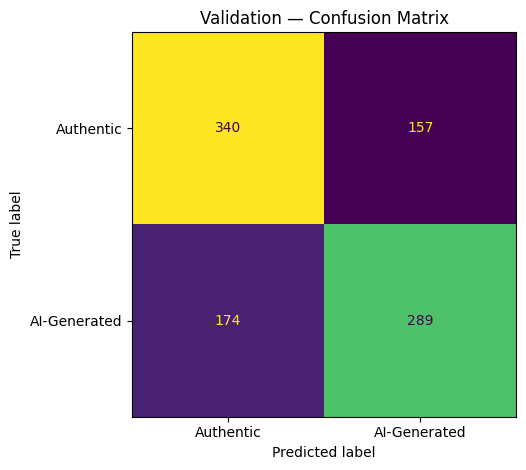

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, precision_score, recall_score

y_pred = model.predict(X_val)

print(classification_report(y_val, y_pred, target_names=["Authentic", "AI-Generated"]))
print(f"Precision : {precision_score(y_val, y_pred):.4f}")
print(f"Recall    : {recall_score(y_val, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_val, y_pred):.4f}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_val, y_pred),
    display_labels=["Authentic", "AI-Generated"]
)
disp.plot(colorbar=False)
plt.title("Validation — Confusion Matrix")
plt.tight_layout()
plt.show()

## 8. Inference on Test Set

In [ ]:
print("Extracting test features...")
X_test, _ = build_matrix(test_df)

test_df["prediction"] = model.predict(X_test)

print("Prediction distribution:")
print(test_df["prediction"].value_counts().rename({0: "authentic", 1: "ai_generated"}))

submission = test_df[["image_id", "prediction"]]
submission.to_csv("submission.csv", index=False)
print("\nSaved → submission.csv")
submission.head()

Extracting test features...


100%|██████████| 2058/2058 [00:39<00:00, 51.73it/s]


Prediction distribution:
prediction
authentic       1076
ai_generated     982
Name: count, dtype: int64

Saved → submission.csv


,image_id,prediction
0,3ecf1af5-6a8f-416a-9b4c-df9f2e0a0a80.jpg,1
1,2789b3fe-a337-4dc2-b42c-8bccde1f68fb.jpg,1
2,01a342c6-c3fc-4b55-8c22-13c1a556ba87.jpg,0
3,ac784910-b461-498d-b3a8-50b1e4116b11.jpg,0
4,6dcd4df6-7447-4bcf-a29b-f7f53b4c3ed4.jpg,0



## 9. What's Next?

This baseline is intentionally minimal — it is just a starting point. Here are some broad areas worth thinking about, but you are free to explore in any direction you choose:

- **Image representation** — how you turn an image into numbers matters a lot
- **Model choice** — different models have different strengths
- **Training strategy** — how you train can be just as important as what you train
- **Data** — think about what the data is telling you

There is no single right answer. Be creative, experiment, and have fun!